In [70]:
import numpy as np
import pandas as pd
import pyopenms as ms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from itertools import product
import string
from scipy.signal import find_peaks

# generate data table
Peptide sequences from library generation, generate [M+H]+ and [M+2H]2+

In [71]:
curated_library_unirep = np.load('data/curated_peptide_list.npy')

#Define modifications
linear = 'TAPAYDG'
lin_het_red = 'T[-18.01]APAYDG'
lin_het_red2 = 'T[-18.01]APAYDG[-18.01]'
lin_het_ox = 'T[-20.02]APAYDG'
lin_het_ox2 = 'T[-20.02]APAYDG[-20.02]'
lin_het_ox12 = 'T[-18.01]APAYDG[-20.02]'

cyc = "TAP[-18.01]"
mods = [linear, lin_het_red, lin_het_ox, lin_het_red2, lin_het_ox2,  lin_het_ox12, cyc]

# create pandas dataframe containing peptide seqs and their mass
df = pd.DataFrame(columns = ['linear', 'L(m+1)', 'L(m+2)', 'L(m+3)',
                             'lin+het+red', 'LHR(m+1)', 'LHR(m+2)', 'LHR(m+3)',
                             'lin+het+ox', 'LHO(m+1)', 'LHO(m+2)', 'LHO(m+3)',
                             'lin+het+red2', 'LHR2(m+1)', 'LHR2(m+2)', 'LHR2(m+3)', 
                             'lin+het+ox2', 'LHO2(m+1)', 'LHO2(m+2)', 'LHO2(m+3)', 
                             'lin+het+o1x2', 'LHO1x2(m+1)', 'LHO1x2(m+2)', 'LHO1x2(m+3)',
                             'cyclic', 'C(m+1)', 'C(m+2)', 'C(m+3)'])

for j, pep in enumerate(curated_library_unirep):
    d = []
    for suffix in mods:
        seq_str = pep + suffix
        d.append(seq_str)
        seq = ms.AASequence.fromString(seq_str)
        for i in range(1,4):
            d.append(seq.getMonoWeight(ms.Residue.ResidueType.Full, int(i))/float(i))
    df.loc[j] = d

rows = list(string.ascii_uppercase[:8][::-1])
cols = list(range(1,13))
df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]

In [4]:
df.to_csv('data/peptide_mass_table.csv')
df.head()

,linear,L(m+1),L(m+2),L(m+3),lin+het+red,LHR(m+1),LHR(m+2),LHR(m+3),lin+het+ox,LHO(m+1),...,LHO2(m+3),lin+het+o1x2,LHO1x2(m+1),LHO1x2(m+2),LHO1x2(m+3),cyclic,C(m+1),C(m+2),C(m+3),well
0,DVQAFTAPAYDG,1254.563716,627.785496,418.859423,DVQAFT[-18.01]APAYDG,1236.553151,618.780214,412.855901,DVQAFT[-20.02]APAYDG,1234.543716,...,405.510685,DVQAFT[-18.01]APAYDG[-20.02],1216.526936,608.767106,406.180496,DVQAFTAP[-18.01],830.404299,415.705788,277.472951,A1
1,GYLKWTAPAYDG,1341.647385,671.327331,447.887313,GYLKWT[-18.01]APAYDG,1323.636820,662.322048,441.883791,GYLKWT[-20.02]APAYDG,1321.627385,...,434.538574,GYLKWT[-18.01]APAYDG[-20.02],1303.610605,652.308941,435.208386,GYLKWTAP[-18.01],917.487969,459.247623,306.500841,A2
2,GAEWRTAPAYDG,1293.585848,647.296562,431.866800,GAEWRT[-18.01]APAYDG,1275.575283,638.291280,425.863279,GAEWRT[-20.02]APAYDG,1273.565848,...,418.518062,GAEWRT[-18.01]APAYDG[-20.02],1255.549068,628.278172,419.187874,GAEWRTAP[-18.01],869.426431,435.216854,290.480328,A3
3,IDFVKTAPAYDG,1296.647051,648.827164,432.887201,IDFVKT[-18.01]APAYDG,1278.636486,639.821881,426.883680,IDFVKT[-20.02]APAYDG,1276.627051,...,419.538463,IDFVKT[-18.01]APAYDG[-20.02],1258.610271,629.808774,420.208275,IDFVKTAP[-18.01],872.487635,436.747456,291.500729,A4
4,WLYKDTAPAYDG,1399.652865,700.330071,467.222473,WLYKDT[-18.01]APAYDG,1381.642300,691.324788,461.218951,WLYKDT[-20.02]APAYDG,1379.632865,...,453.873734,WLYKDT[-18.01]APAYDG[-20.02],1361.616085,681.311681,454.543546,WLYKDTAP[-18.01],975.493449,488.250363,325.836001,A5


In [72]:
def peak_detect(trace, sensitivity=2.0):
    '''peakdetection algorithm to detect peaks of linear 
    peptide and exclude the elution time from other peptides'''
    peaks, properties = find_peaks(trace, distance=100, 
                                   height=sensitivity*trace.std())
    argmax = properties['peak_heights'].argmax()
    maxpeak = peaks[argmax]
    return(int(maxpeak-10), int(maxpeak+10))
    

[ 72 253] 
 {'peak_heights': array([ 30765., 276631.])}
1713


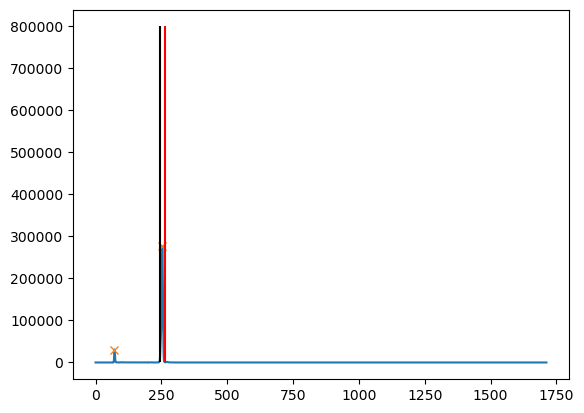

In [91]:
infile='data/PatDf-ArtG/231007-patdf-argox-rep-D7_2d-43_Y-D7_1_27965.mzML'
exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
cyclic_ions =  ['LHR(m+1)', 'LHR(m+2)', 'LHR(m+3)']
exp_ions = linear_ions + cyclic_ions
lin_ions = df.loc[38, linear_ions]
ions = df.loc[exp_num, exp_ions] # get the defined ions

lin_ions = df.loc[exp_num, linear_ions] # define linear ions for peak detection
peptide = df.loc[exp_num, 'linear'] # get peptide sequence
ion = ions[0]
exp = ms.MSExperiment()
ms.MzMLFile().load(infile, exp)
N_scans = len(exp.getSpectra())
intensity = np.zeros((len(range(750)), N_scans))
for i in range(N_scans):
    rt = exp.getSpectrum(i).getRT()
    if (rt>20) and (rt<240):
        mass, count = exp.getSpectrum(i).get_peaks()
        mask = (mass > (ion - 0.1)) & (mass < (ion + 0.1))
        ic = count[mask].sum()
        intensity[j,i] = ic
trace=intensity.sum(axis=0)
#x, y = peak_detect(trace,lag=15, threshold=1.5)
peaks, properties = find_peaks(trace, distance=100, height=trace.std())

plt.plot(trace)
plt.plot(peaks, trace[peaks], 'x')

plt.vlines(peaks[properties['peak_heights'].argmax()]-10,ymin=0,ymax=800000, colors='k')
plt.vlines(peaks[properties['peak_heights'].argmax()]+10,ymin=0,ymax=800000, colors='r')

print(peaks, '\n', properties)
print(N_scans)

In [74]:
def extract_ioncount(exp, ions, rt_start, rt_end, MZ_tol=0.1):
    '''
    returns list of extracted ion counts of an mzML and
    intensity over time for a given spectrum 
    exp : [pyOpenMS experiment]
    ions: iterable of desired ion m/z values [float]
    rt_start: start acquisition retentiontime [seconds]
    rt_end: end acquisition retentiontime [seconds]
    MZ_tol: tolerance interval for m/z [float]
    '''
    N_scans = len(exp.getSpectra())
    ionCounts = np.zeros(len(ions))
    if PLOT==True:
        intensity = np.zeros((len(ions), N_scans))
    else: 
        intensity = None
        
    for j, ion in enumerate(ions):
        for i in range(N_scans):
            rt = exp.getSpectrum(i).getRT()
            if (rt>rt_start) and (rt<rt_end):
                mass, count = exp.getSpectrum(i).get_peaks()
                mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                ic = count[mask].sum()
                ionCounts[j] += ic
                
                if PLOT==True:
                    intensity[j,i] = ic
         
    return(list(ionCounts), intensity)

In [75]:
def extract_ioncount2(exp, ions, rt_start, rt_end, MZ_tol=0.1, sensitivity=3):
    '''
    returns list of extracted ion counts of an mzML and
    intensity over time for a given spectrum 
    exp : [pyOpenMS experiment]
    ions: iterable of desired ion m/z values [float]
    rt_start: start acquisition retentiontime [seconds]
    rt_end: end acquisition retentiontime [seconds]
    MZ_tol: tolerance interval for m/z [float]
    '''
    N_scans = len(exp.getSpectra())
    ionCounts = np.zeros(len(ions))
    
    intensity = np.zeros((len(ions), N_scans))
            
    for j, ion in enumerate(ions):
        if j <= 2:
            for i in range(N_scans):
                rt = exp.getSpectrum(i).getRT()
                if (rt > rt_start) and (rt < rt_end):
                    mass, count = exp.getSpectrum(i).get_peaks()
                    mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                    ic = count[mask].sum()
                    intensity[j, i] = ic
            x1, x2 =  peak_detect(intensity.sum(axis=0), sensitivity=sensitivity)
        else:
            for i in range(N_scans):
                rt = exp.getSpectrum(i).getRT()
                if (rt>rt_start) and (rt<rt_end):
                    mass, count = exp.getSpectrum(i).get_peaks()
                    mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                    ic = count[mask].sum()
                    intensity[j,i] = ic
        intensity[3:, x1:x2] = 0.0
        ionCounts = intensity.sum(axis=1)
    return(list(ionCounts), intensity)

In [76]:
def make_heatmap(data, name, incubation_time, quantity='conversion', save=False):
    rows = list(string.ascii_uppercase[:8][::-1])
    cols = list(range(1,13))
    quantity = 'conversion'

    data = np.array(result_df['conversion']).reshape((8,12))

    fig, ax = plt.subplots(dpi=400)
    im = ax.imshow(data, extent=[0, 12, 0, 8] )
    #ax.pcolormesh(data, edgecolors='k', linewidth=2)
    ax.grid(which = 'minor',color='w', linestyle='-', linewidth=2)
    plt.xticks(np.arange(len(cols))+0.5, labels=cols)
    ax.set_yticks(np.arange(len(rows))+0.5, labels=rows)
    plt.xlim(0,12)
    title = name+' '+quantity+', '+incubation_time
    plt.title(title)

    #ax.grid(color='k', linestyle='-', linewidth=2)
    for j, i in product(np.arange(len(cols)),np.arange(len(rows))):
        l = ax.axvline(j, color='k', linewidth=2)
        l = ax.axhline(i, color='k', linewidth=2)

    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.028, pad=0.04)
    cbar.ax.set_ylabel('% '+quantity, rotation=-90, va="bottom")
    if save == True:
        plt.savefig(title+'.png')

# Analyze PatG - 2 day reaction

In [51]:
PLOT=False
data_dir = 'data/PatG-2d/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
cyclic_ions =  ['C(m+1)', 'C(m+2)', 'C(m+3)']
exp_ions = linear_ions + cyclic_ions

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = int(0.4*60)
end = 240
xlab = np.linspace(start, end, intensity.shape[1])


In [52]:
elution_times = []
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    lin_ions = df.loc[exp_num, linear_ions] # define linear ions for peak detection
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    #ion_count, intensity = extract_ioncount(exp, ions, start, end)
    ion_count, intensity = extract_ioncount2(exp, ions, start, end)
    
    if PLOT==True:
        '''for i in range(len(ions)):
            col = ['r', 'b']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            else:
                plt.plot(intensity[i], color = col[1])'''
        xlab = np.linspace(start, end, intensity.shape[1])
        plt.plot(xlab, intensity[:3, :].sum(axis=0), color='r', alpha=0.7)        
        plt.plot(xlab, intensity[3:, :].sum(axis=0), color='b', alpha=0.7)   
        plt.xlabel('Elution time (s)')
        plt.ylabel('Ion Count')
        plt.title('PatG + '+str(exp_num+1)+' '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='cyclic peptide')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch])
        plt.savefig('output_patg/'+str(exp_num)+'_PatG_'+peptide)
        plt.clf()
    xlab = np.linspace(start, end, intensity.shape[1])
    elution_times.append([xlab[intensity[:3,:].sum(axis=0).argmax()], 
                          xlab[intensity[3:,:].sum(axis=0).argmax()]])
    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['C(tot)'] = result_df.loc[:,['C(m+1)', 'C(m+2)', 'C(m+3)']].sum(axis=1)

# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,'C(tot)']/result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)*100

In [54]:
# sort again by index
result_df.sort_index(inplace=True)
# add names for wells to the data
rows = list(string.ascii_uppercase[:8][::-1])
cols = list(range(1,13))
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]

# calculate total ion count of all linear and cyclic peptides
result_df['tot_ions'] = result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,well,tot_ions
0,DVQAFTAPAYDG,7531986.0,19669095.0,59709.0,88516.0,69056.0,2540.0,27260790.0,160112.0,0.583905,A1,27420902.0
1,GYLKWTAPAYDG,1461095.0,24657462.0,447433.0,529422.0,535984.0,4738.0,26565990.0,1070144.0,3.872264,A2,27636134.0
2,GAEWRTAPAYDG,1017100.0,22716457.0,547222.0,61689.0,236353.0,2224.0,24280779.0,300266.0,1.221535,A3,24581045.0
3,IDFVKTAPAYDG,2002792.0,39992708.0,954651.0,128221.0,145504.0,2890.0,42950151.0,276615.0,0.639916,A4,43226766.0
4,WLYKDTAPAYDG,1185543.0,33413060.0,812739.0,588560.0,695039.0,7799.0,35411342.0,1291398.0,3.518533,A5,36702740.0


In [56]:
result_df[['elultion_time_Linear(s)', 'elution_time_Cyclic(s)']] = elution_times
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,well,tot_ions,elultion_time_Linear(s),elution_time_Cyclic(s)
0,DVQAFTAPAYDG,7531986.0,19669095.0,59709.0,88516.0,69056.0,2540.0,27260790.0,160112.0,0.583905,A1,27420902.0,55.326316,64.168421
1,GYLKWTAPAYDG,1461095.0,24657462.0,447433.0,529422.0,535984.0,4738.0,26565990.0,1070144.0,3.872264,A2,27636134.0,69.194623,80.051432
2,GAEWRTAPAYDG,1017100.0,22716457.0,547222.0,61689.0,236353.0,2224.0,24280779.0,300266.0,1.221535,A3,24581045.0,62.503799,77.400351
3,IDFVKTAPAYDG,2002792.0,39992708.0,954651.0,128221.0,145504.0,2890.0,42950151.0,276615.0,0.639916,A4,43226766.0,68.463158,78.947368
4,WLYKDTAPAYDG,1185543.0,33413060.0,812739.0,588560.0,695039.0,7799.0,35411342.0,1291398.0,3.518533,A5,36702740.0,57.094737,65.052632


## False positive filtering
Crosscompare the total ion count with conversion values. Spectra were sorted by total ion count and all spectra were visually checked. 

**Observation**: Measurements with a total ion count < 1739627.0 seemed to be of poor quality and need to be repeated.

In [57]:
result_df.sort_values('tot_ions').head(14)

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,well,tot_ions,elultion_time_Linear(s),elution_time_Cyclic(s)
78,YGENWTAPAYDG,170880.0,1279725.0,5910.0,115782.0,84833.0,77619.0,1456515.0,278234.0,16.038862,G7,1734749.0,80.842105,106.484211
94,ENFRDTAPAYDG,15955.0,1519895.0,76069.0,103871.0,66078.0,104574.0,1611919.0,274523.0,14.552422,H11,1886442.0,64.271186,75.885447
79,WEYGQTAPAYDG,427540.0,4466579.0,37548.0,143597.0,159267.0,14595.0,4931667.0,317459.0,6.047845,G8,5249126.0,61.998831,73.486850
92,FAKIYTAPAYDG,101262.0,5194129.0,181091.0,108500.0,80884.0,272819.0,5476482.0,462203.0,7.782918,H9,5938685.0,54.550555,62.756283
9,LDWEFTAPAYDG,878165.0,6895417.0,67010.0,64781.0,55680.0,6743.0,7840592.0,127204.0,1.596477,A10,7967796.0,65.659848,79.041496
46,FDWGATAPAYDG,1815371.0,8180204.0,53396.0,59666.0,74642.0,5547.0,10048971.0,139855.0,1.372631,D11,10188826.0,55.794393,67.780374
17,TYGFGTAPAYDG,2763860.0,6797974.0,17419.0,912232.0,194187.0,10590.0,9579253.0,1117009.0,10.442985,B6,10696262.0,67.149533,76.990654
13,YDAHATAPAYDG,208090.0,10134951.0,218158.0,180411.0,180394.0,2637.0,10561199.0,363442.0,3.326810,B2,10924641.0,50.652632,48.757895
31,DGYKNTAPAYDG,250686.0,10496785.0,142339.0,14480.0,25623.0,119819.0,10889810.0,159922.0,1.447293,C8,11049732.0,58.045534,61.702277
87,REYGNTAPAYDG,402565.0,11094157.0,351214.0,47331.0,48635.0,92215.0,11847936.0,188181.0,1.563469,H4,12036117.0,70.303738,88.345794


array([[<Axes: title={'center': 'conversion'}>,
        <Axes: title={'center': 'tot_ions'}>]], dtype=object)

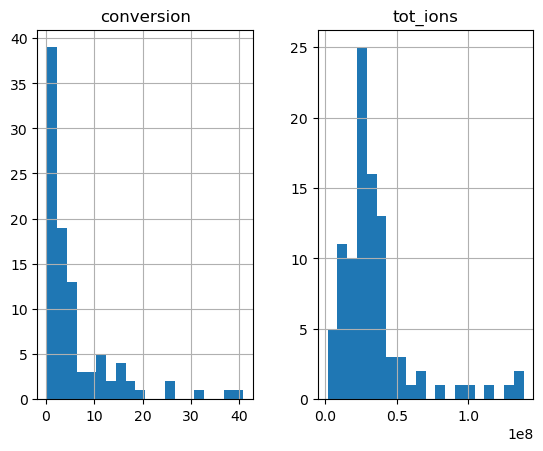

In [58]:
result_df.loc[:,['conversion', 'tot_ions']].hist(bins=20)

**Observation:** The top conversions stemmed from low ion count measurements. 

In [59]:
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

,L(tot),C(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,3.132383e+07,2.858139e+06,6.053113,3.418197e+07
std,2.208124e+07,6.347503e+06,7.818003,2.595528e+07
min,1.456515e+06,5.234200e+04,0.292680,1.734749e+06
25%,1.834159e+07,2.815828e+05,1.368696,2.119266e+07
50%,2.750751e+07,6.960595e+05,2.903329,2.822768e+07
75%,3.583162e+07,1.813864e+06,6.931777,3.774671e+07
max,1.306356e+08,4.568278e+07,40.813287,1.384925e+08


__filter out samples with low ion count__

In [60]:
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < 1739627.0, 'conversion'] = 0
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

,L(tot),C(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,3.132383e+07,2.858139e+06,5.886042,3.418197e+07
std,2.208124e+07,6.347503e+06,7.773610,2.595528e+07
min,1.456515e+06,5.234200e+04,0.000000,1.734749e+06
25%,1.834159e+07,2.815828e+05,1.353149,2.119266e+07
50%,2.750751e+07,6.960595e+05,2.783404,2.822768e+07
75%,3.583162e+07,1.813864e+06,6.197900,3.774671e+07
max,1.306356e+08,4.568278e+07,40.813287,1.384925e+08


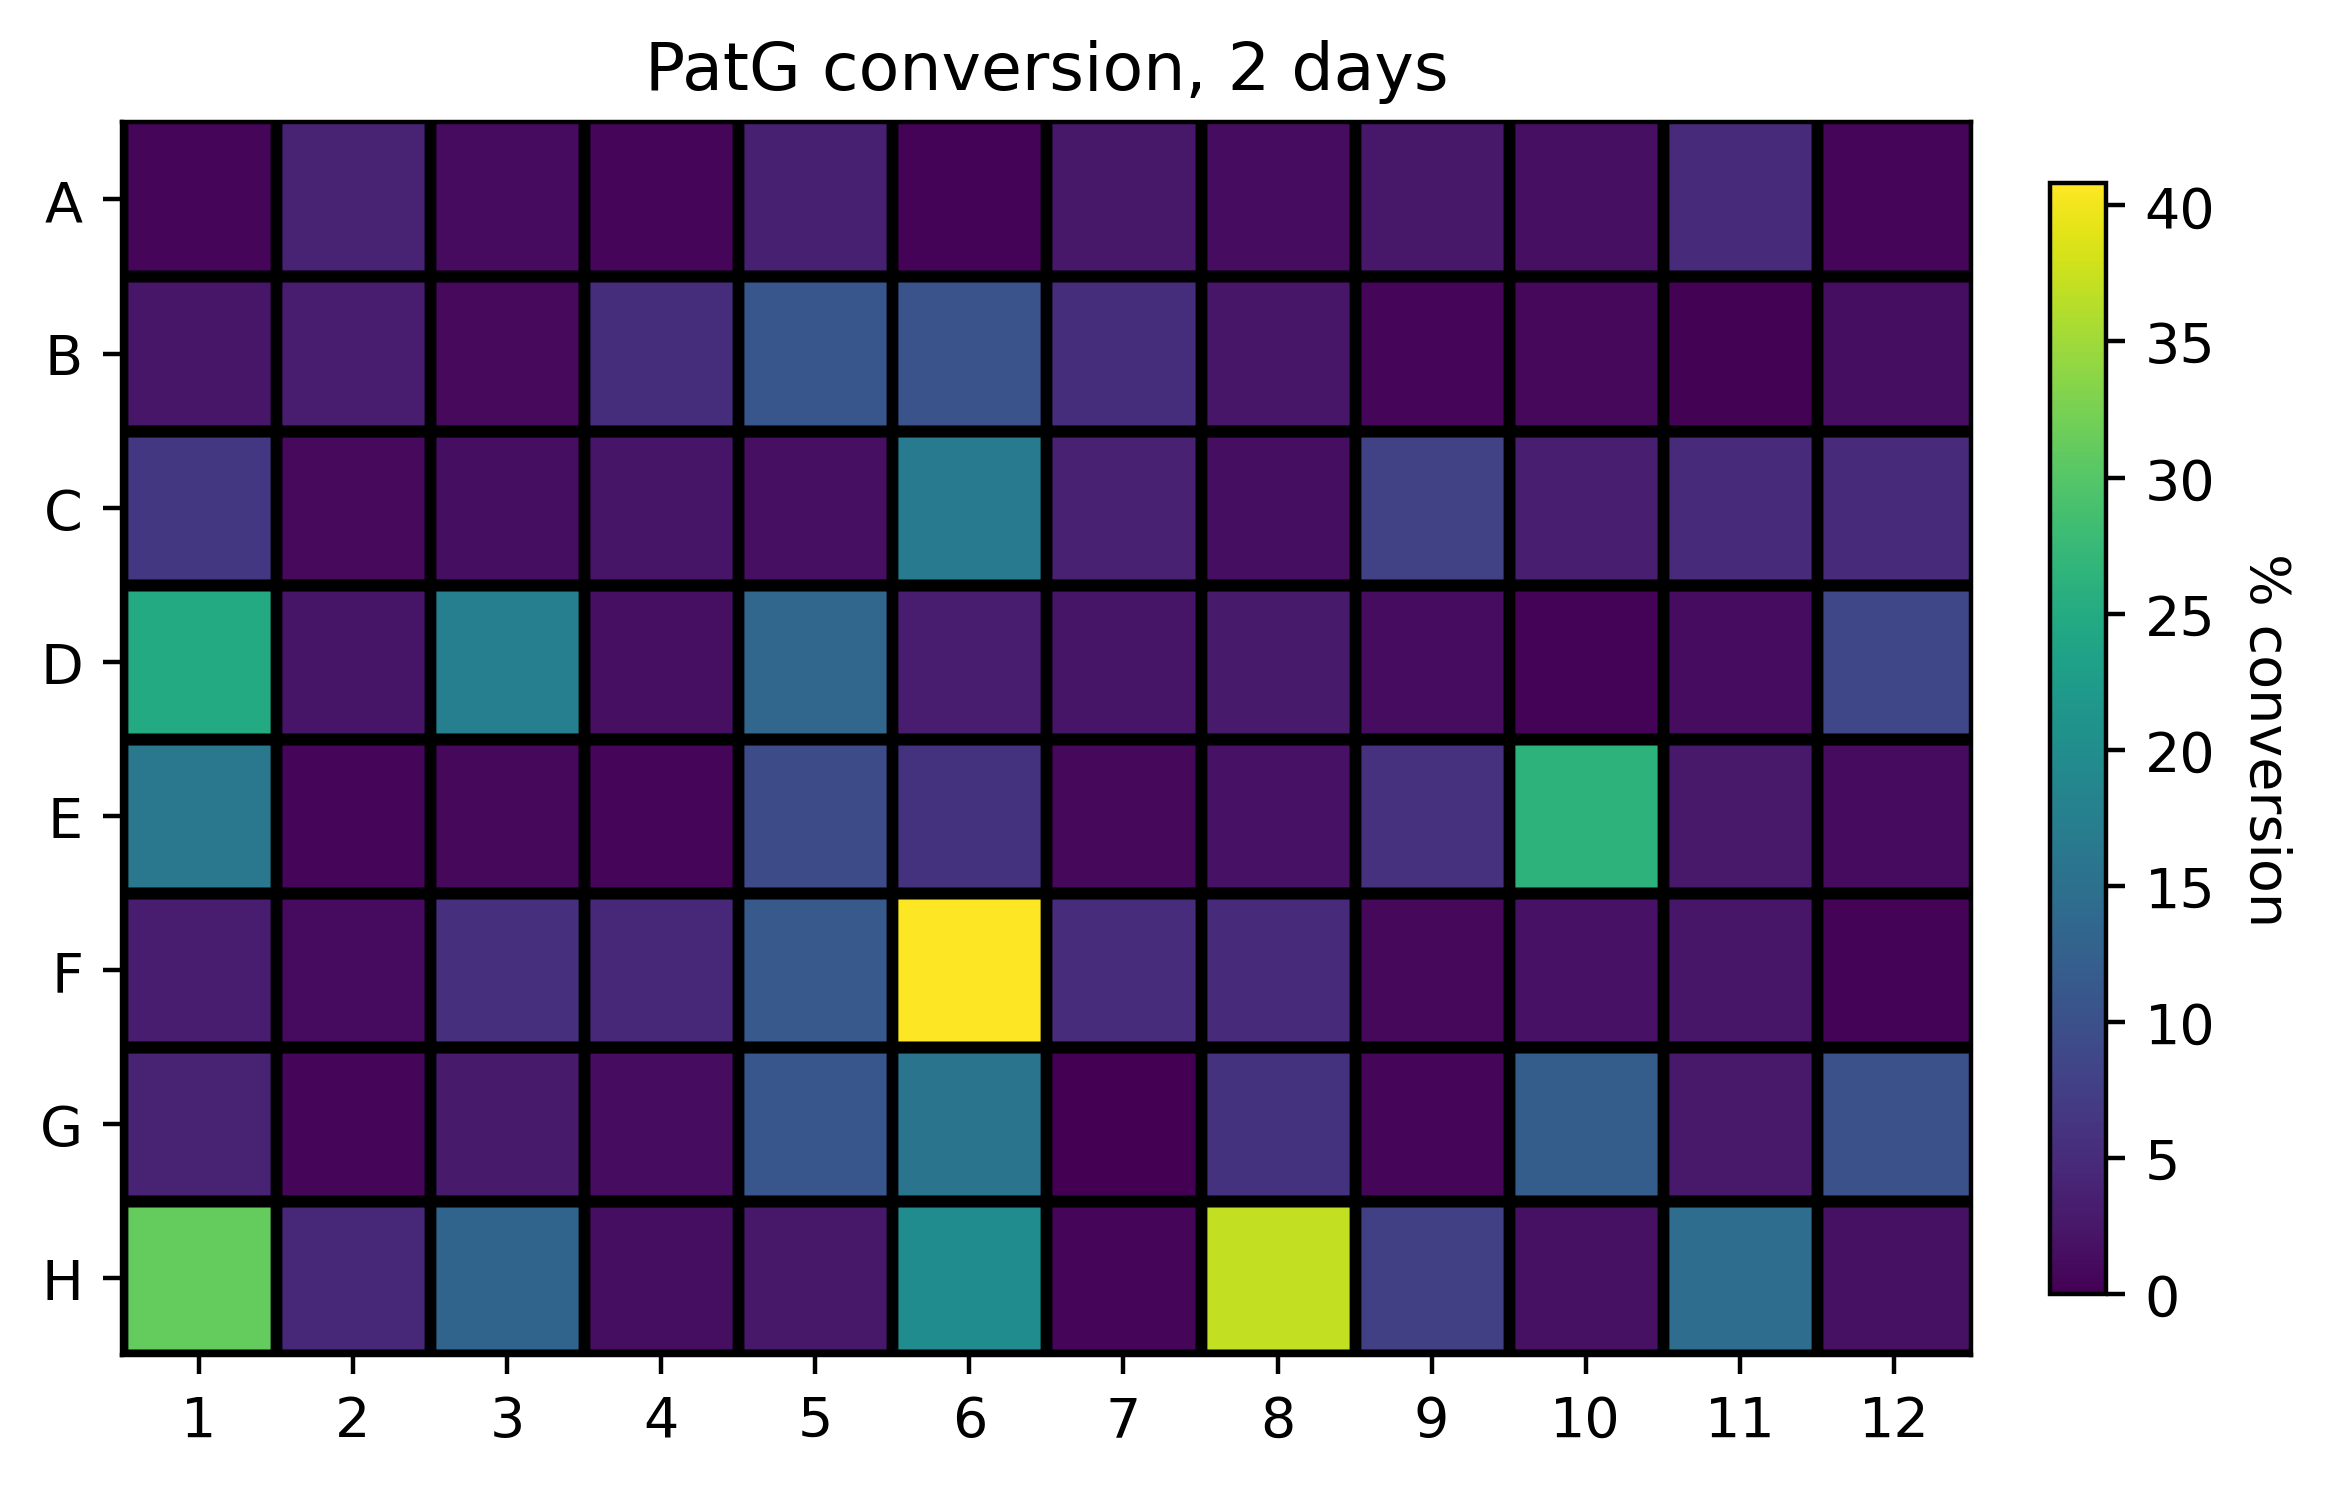

In [61]:
make_heatmap(result_df, 'PatG', '2 days', 'conversion', save=True)

## top 10 candidates for cyclization with PatG

In [62]:
result_df.to_csv('PatG-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['peptide','conversion']].head(10)

,peptide,conversion
65,ARYFQTAPAYDG,40.813287
91,WHRFTTAPAYDG,37.083744
84,IFRYETAPAYDG,31.223747
57,HRFLWTAPAYDG,26.392587
36,YRGAWTAPAYDG,24.969825
89,YLEKFTAPAYDG,19.787914
38,QRWETTAPAYDG,17.682467
29,VENWYTAPAYDG,16.836680
48,GRFYKTAPAYDG,16.285952
77,GFDKWTAPAYDG,15.739276


# Analyze PatDfusion + ArtGox - 2 day reaction

In [102]:
PLOT=False
data_dir = 'data/PatDf-ArtG/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
lhr = ['LHR(m+1)', 'LHR(m+2)','LHR(m+3)']
lho = ['LHO(m+1)', 'LHO(m+2)','LHO(m+3)' ]
lhmult=['LHR2(m+1)', 'LHR2(m+2)', #'LHR2(m+3)', 
'LHO2(m+1)', 'LHO2(m+2)', #'LHO2(m+3)', 
'LHO1x2(m+1)', 'LHO1x2(m+2)']#, 'LHO1x2(m+3)']

#combined list with expected ions
exp_ions = linear_ions + lhr + lho# + lhmult

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = int(0.4*60)
end = 240

In [103]:
exp_ions

['L(m+1)',
 'L(m+2)',
 'L(m+3)',
 'LHR(m+1)',
 'LHR(m+2)',
 'LHR(m+3)',
 'LHO(m+1)',
 'LHO(m+2)',
 'LHO(m+3)']

In [104]:
elution_times = []
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    ion_count, intensity = extract_ioncount2(exp, ions, start, end)
    #ion_count, intensity = extract_ioncount(exp, ions, start, end)

    if PLOT==True:
        '''for i in range(len(ions)):
            col = ['r', 'b', 'k']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            elif i >= 6:
                plt.plot(intensity[i], color = col[2])
            else:
                plt.plot(intensity[i], color = col[1])'''
        xlab = np.linspace(start, end, intensity.shape[1])
        plt.plot(xlab, intensity[:3, :].sum(axis=0), color='r', alpha = 0.7)        
        plt.plot(xlab, intensity[3:6, :].sum(axis=0), color='b', alpha = 0.7)
        plt.plot(xlab, intensity[6:, :].sum(axis=0), color='k', alpha = 0.7)
        plt.xlabel('Elution time (s)')
        plt.ylabel('Ion Count')
        plt.title('PatDf+ArtGox '+str(exp_num+1)+' '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='heterocyclic reduced')
        black_patch = mpatches.Patch(color='k', label='heterocyclic oxidized')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch, black_patch])
        plt.savefig('output_patdf_artgox/'+str(exp_num)+'_PatDf_ArtGox_'+peptide)
        plt.clf()
    xlab = np.linspace(start, end, intensity.shape[1])
    elution_times.append([xlab[intensity[:3,:].sum(axis=0).argmax()], 
                          xlab[intensity[3:6,:].sum(axis=0).argmax()],
                          xlab[intensity[6:,:].sum(axis=0).argmax()]])

    result_df.loc[exp_num] = [peptide]+ion_count

In [113]:
# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['LHR(tot)'] = result_df.loc[:,lhr].sum(axis=1)
result_df['LHO(tot)'] = result_df.loc[:,lho].sum(axis=1)
#result_df['LH_MULTI'] = result_df.loc[:,lhmult].sum(axis=1)


# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,['LHO(tot)','LHR(tot)']].sum(axis=1)/result_df.loc[:,['LHO(tot)', 'LHR(tot)', 'L(tot)']].sum(axis=1)*100
result_df['tot_ions'] = result_df.loc[:, exp_ions].sum(axis=1)

result_df.sort_values('tot_ions').head(10)

,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),elultion_time_Linear(s),elution_time_LHR(s),elution_time_LHO(s),well,conversion,tot_ions
94,ENFRDTAPAYDG,7032.0,200843.0,122031.0,7519.0,85331.0,80283.0,8580.0,57602.0,66748.0,329906.0,173133.0,132930.0,54.767075,59.180385,59.810858,H11,48.125459,635969.0
3,IDFVKTAPAYDG,14814.0,324168.0,121841.0,9057.0,132883.0,122473.0,10264.0,95745.0,493943.0,460823.0,264413.0,599952.0,66.644860,67.906542,70.051402,A4,65.225840,1325188.0
10,QFWKVTAPAYDG,11781.0,277895.0,357422.0,14133.0,248203.0,234796.0,13601.0,114503.0,138698.0,647098.0,497132.0,266802.0,41.042665,75.127995,58.969024,A11,54.140090,1411032.0
23,DQFWHTAPAYDG,2922.0,352249.0,111846.0,1951.0,268807.0,89246.0,1076.0,244099.0,412457.0,467017.0,360004.0,657632.0,81.061368,52.530684,83.207481,B12,68.543693,1484653.0
0,DVQAFTAPAYDG,15323.0,116145.0,243585.0,22597.0,140581.0,142358.0,22002.0,240757.0,868530.0,375053.0,305536.0,1131289.0,75.663158,56.842105,64.926316,A1,79.300317,1811878.0
25,ADKFETAPAYDG,15686.0,1686943.0,91980.0,16393.0,205159.0,56407.0,3067.0,36528.0,198568.0,1794609.0,277959.0,238163.0,55.542056,60.588785,61.093458,C2,22.335876,2310731.0
92,FAKIYTAPAYDG,27654.0,2544679.0,111889.0,2948.0,56098.0,25372.0,1753.0,23491.0,21758.0,2684222.0,84418.0,47002.0,62.756283,65.028638,59.852718,H9,4.667497,2815642.0
9,LDWEFTAPAYDG,438920.0,4638345.0,52504.0,31577.0,268488.0,16636.0,1881.0,50177.0,7418.0,5129769.0,316701.0,59476.0,80.018692,81.658879,81.785047,A10,6.832196,5505946.0
86,EYWNATAPAYDG,1368004.0,3656905.0,306446.0,40713.0,262530.0,616227.0,2506.0,92976.0,62902.0,5331355.0,919470.0,158384.0,66.063158,61.010526,59.873684,H3,16.817270,6409209.0
37,ERVQKTAPAYDG,17817.0,1394290.0,4805187.0,1000.0,297845.0,232997.0,775.0,28475.0,44605.0,6217294.0,531842.0,73855.0,36.231173,48.462347,62.458844,D2,8.877294,6822991.0


In [108]:
result_df[['elultion_time_Linear(s)', 'elution_time_LHR(s)', 'elution_time_LHO(s)']] = elution_times
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),elultion_time_Linear(s),elution_time_LHR(s),elution_time_LHO(s)
42,FQYTRTAPAYDG,1821763.0,33912668.0,1598128.0,20419.0,1504224.0,326545.0,2188.0,107872.0,122077.0,37332559.0,1851188.0,232137.0,55.920561,57.939252,54.532710
44,LAKWGTAPAYDG,1092605.0,19070884.0,404810.0,14757.0,710213.0,86917.0,2054.0,40845.0,34399.0,20568299.0,811887.0,77298.0,60.441331,62.584939,50.858144
51,WDLKYTAPAYDG,2650906.0,29888649.0,1923017.0,111829.0,4194664.0,391899.0,7336.0,168963.0,72680.0,34462572.0,4698392.0,248979.0,68.842105,70.610526,70.736842
12,ERGFKTAPAYDG,277300.0,7053822.0,20261679.0,5904.0,825239.0,1007005.0,1711.0,69275.0,77290.0,27592801.0,1838148.0,148276.0,50.116822,52.135514,57.434579
68,WAKVDTAPAYDG,900404.0,17632582.0,438110.0,7685.0,724865.0,35715.0,1568.0,47464.0,150275.0,18971096.0,768265.0,199307.0,58.676007,60.567426,112.392294


In [109]:
result_df['LH_MULTI'] = result_df.loc[:, lhmult].sum(axis=1)
result_df['LH_MULTI_conversion'] = result_df.loc[:,'LH_MULTI']/result_df.loc[:,['LH_MULTI', 'LHO(tot)', 'LHR(tot)', 'L(tot)']].sum(axis=1)*100
result_df['conversion'].mean()


KeyError: "None of [Index(['LHR2(m+1)', 'LHR2(m+2)', 'LHO2(m+1)', 'LHO2(m+2)', 'LHO1x2(m+1)',\n       'LHO1x2(m+2)'],\n      dtype='object')] are in the [columns]"

In [114]:
result_df.sort_index(inplace=True)
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]
result_df.sort_values('tot_ions', ascending=True).head()

,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),elultion_time_Linear(s),elution_time_LHR(s),elution_time_LHO(s),well,conversion,tot_ions
94,ENFRDTAPAYDG,7032.0,200843.0,122031.0,7519.0,85331.0,80283.0,8580.0,57602.0,66748.0,329906.0,173133.0,132930.0,54.767075,59.180385,59.810858,H11,48.125459,635969.0
3,IDFVKTAPAYDG,14814.0,324168.0,121841.0,9057.0,132883.0,122473.0,10264.0,95745.0,493943.0,460823.0,264413.0,599952.0,66.644860,67.906542,70.051402,A4,65.225840,1325188.0
10,QFWKVTAPAYDG,11781.0,277895.0,357422.0,14133.0,248203.0,234796.0,13601.0,114503.0,138698.0,647098.0,497132.0,266802.0,41.042665,75.127995,58.969024,A11,54.140090,1411032.0
23,DQFWHTAPAYDG,2922.0,352249.0,111846.0,1951.0,268807.0,89246.0,1076.0,244099.0,412457.0,467017.0,360004.0,657632.0,81.061368,52.530684,83.207481,B12,68.543693,1484653.0
0,DVQAFTAPAYDG,15323.0,116145.0,243585.0,22597.0,140581.0,142358.0,22002.0,240757.0,868530.0,375053.0,305536.0,1131289.0,75.663158,56.842105,64.926316,A1,79.300317,1811878.0


In [42]:
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)','conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,2.183605e+07,1.691171e+06,2.591393e+05,10.621371,2.408673e+07
std,1.276345e+07,1.857516e+06,2.897108e+05,13.780730,1.424884e+07
min,3.299060e+05,9.264400e+04,3.286400e+04,3.089489,9.735730e+05
25%,1.298034e+07,6.319980e+05,1.051158e+05,5.034225,1.421974e+07
50%,2.048314e+07,1.116634e+06,1.652910e+05,6.192059,2.223982e+07
75%,2.786823e+07,2.069885e+06,2.873242e+05,8.648481,3.053830e+07
max,6.093378e+07,1.232108e+07,2.154369e+06,79.636506,6.762145e+07


In [115]:
cutoff = 4826505.0
quantity = 'conversion'
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < cutoff, quantity] = 0
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)', 'unfiltered_conversion', 'conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),unfiltered_conversion,conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,96.000000,9.600000e+01
mean,2.183605e+07,1.546926e+06,2.354608e+05,10.025976,6.459947,2.361843e+07
std,1.276345e+07,1.772165e+06,2.839894e+05,13.691875,5.072218,1.394046e+07
min,3.299060e+05,8.441800e+04,3.139900e+04,2.874655,0.000000,6.359690e+05
25%,1.298034e+07,5.722690e+05,9.066300e+04,4.617602,4.248176,1.381282e+07
50%,2.048314e+07,1.050059e+06,1.360875e+05,5.712347,5.404079,2.200377e+07
75%,2.786823e+07,1.840651e+06,2.534348e+05,7.778969,7.267311,2.993038e+07
max,6.093378e+07,1.206505e+07,2.129515e+06,79.300317,33.105673,6.557729e+07


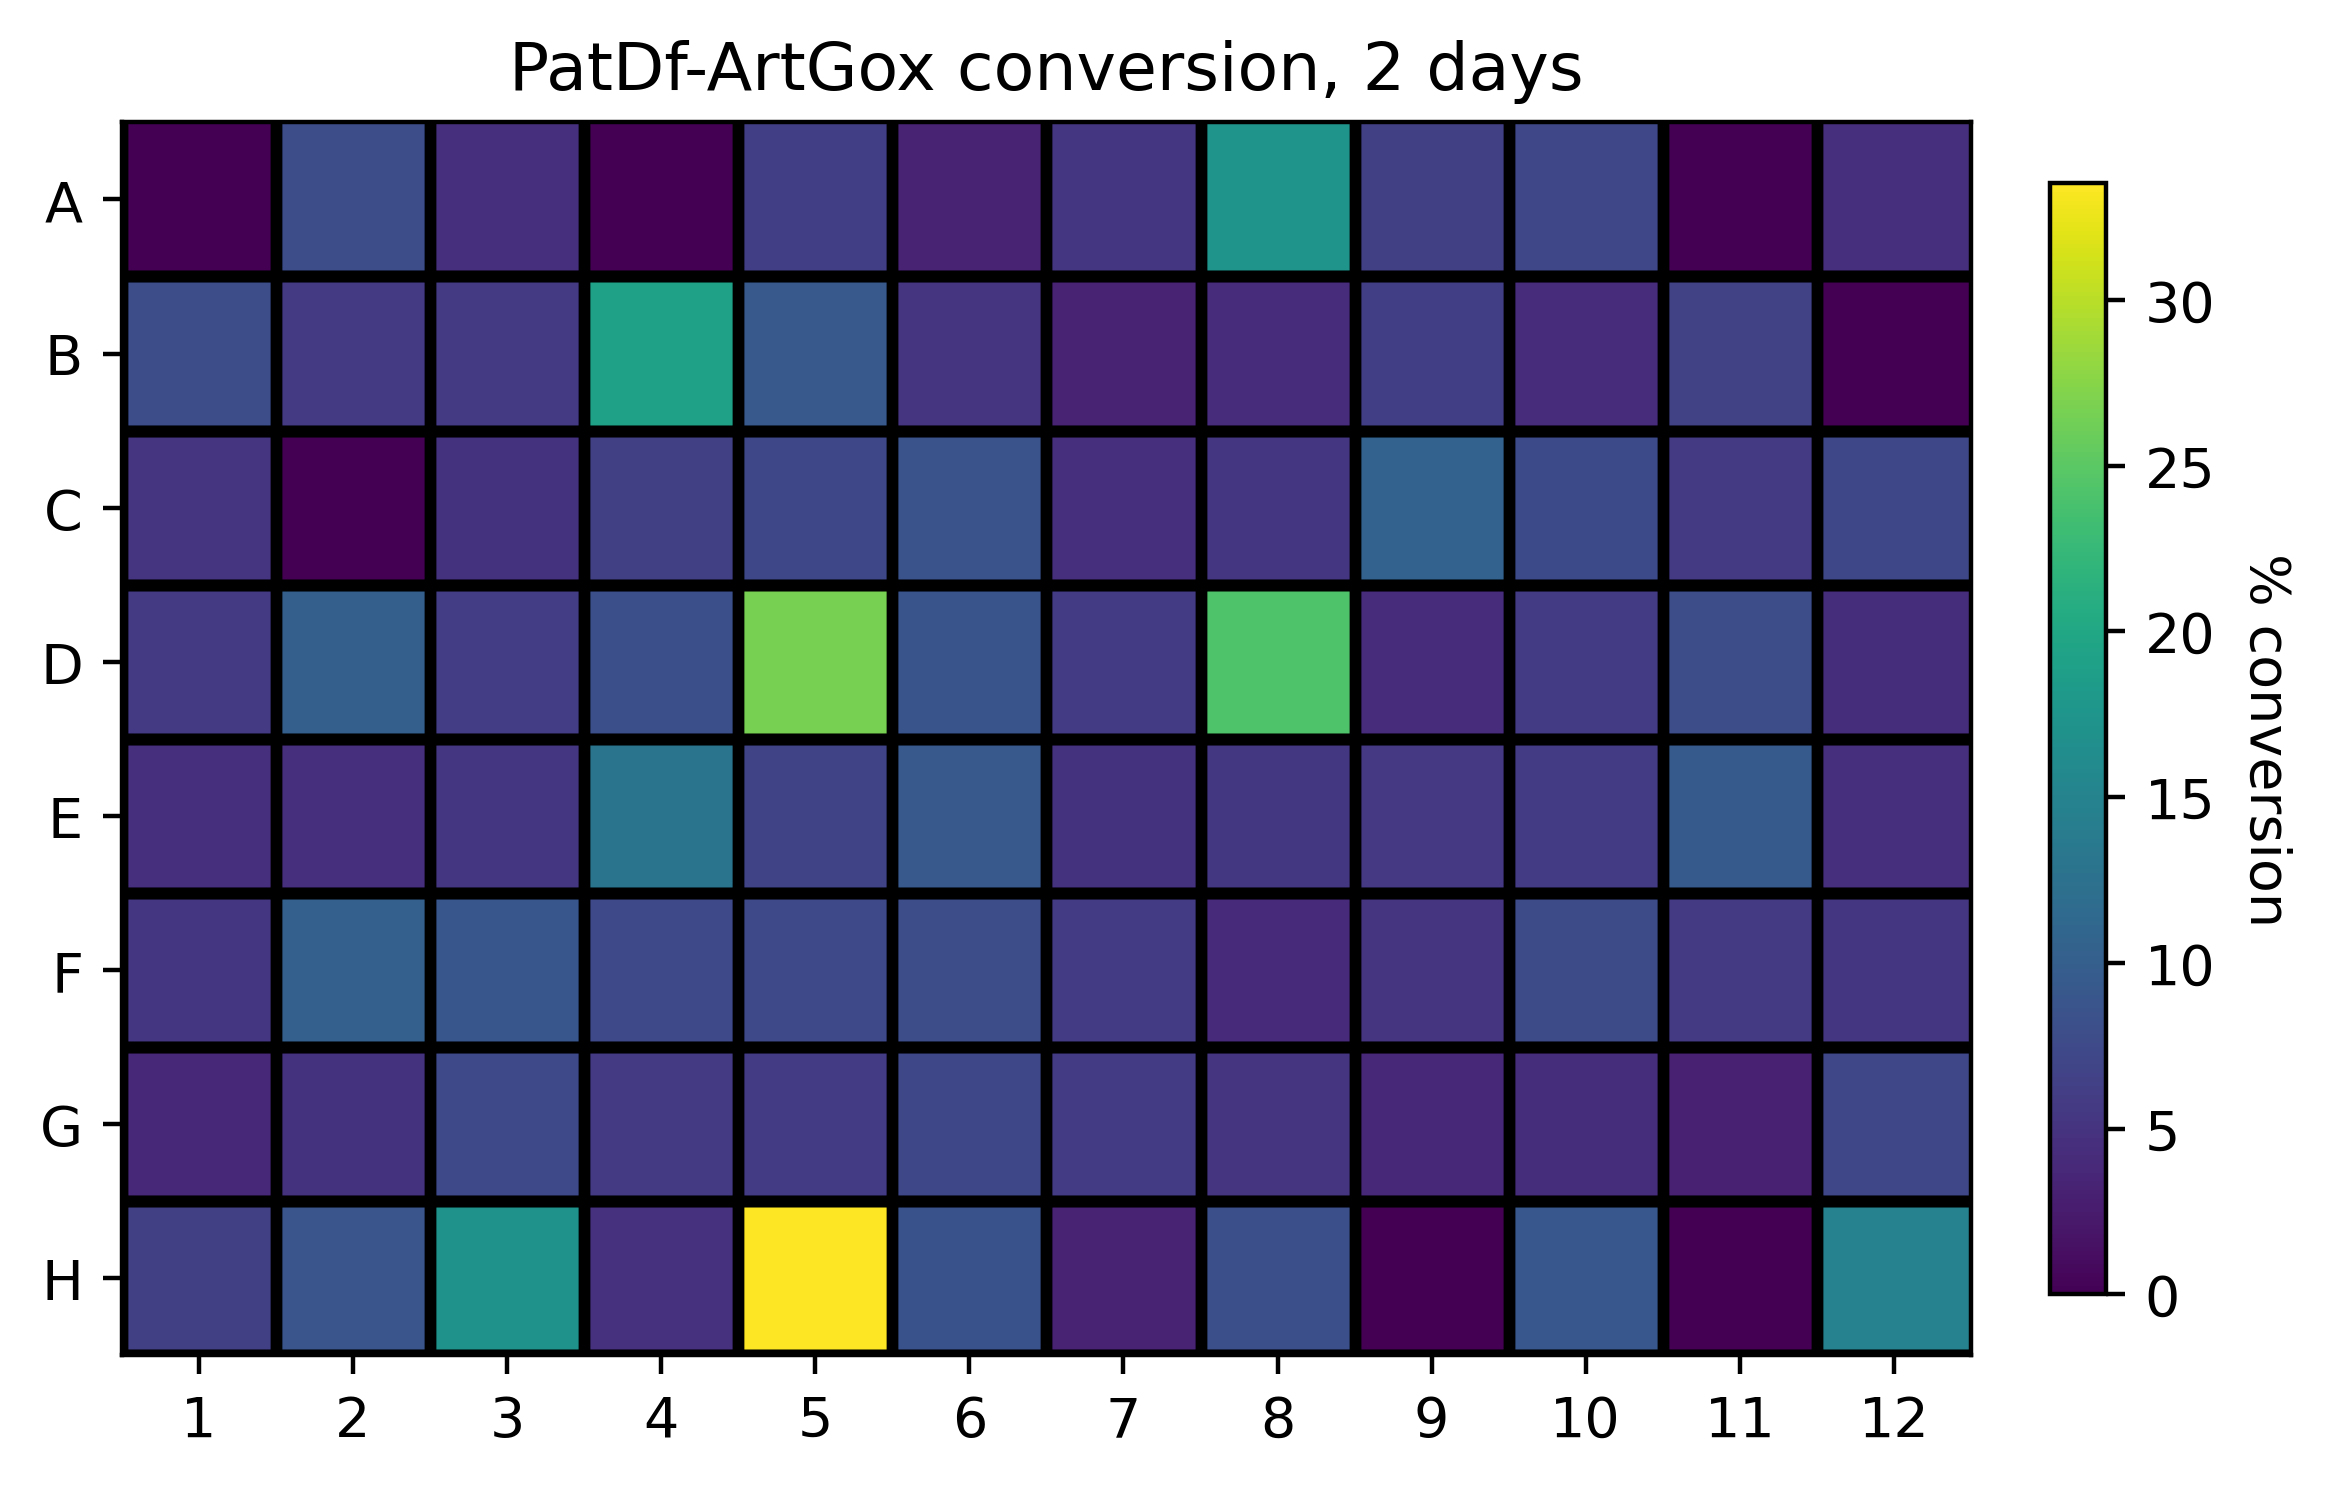

In [44]:
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion', save=True)

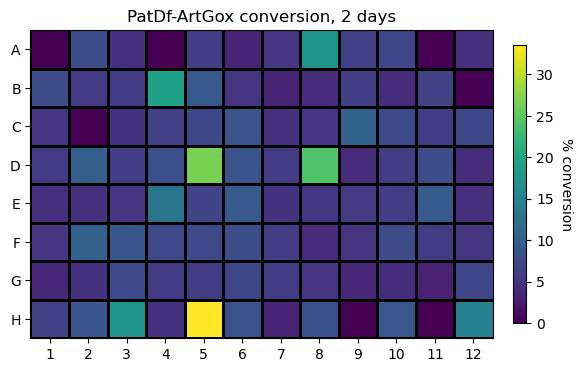

In [50]:
#result_df.loc[result_df['tot_ions'] < cutoff, quantity] = 400000000
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion')

In [116]:
result_df[result_df['conversion']>3e+08].sort_values('well')['well'].to_csv('lowcount_patdf.csv')

In [117]:
result_df.to_csv('result_data/PatDf-ArtGox-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['conversion','peptide','well']].head(10)

,conversion,peptide,well
88,33.105673,YEIAYTAPAYDG,H5
40,26.148884,NFRAFTAPAYDG,D5
43,23.521709,KWENFTAPAYDG,D8
15,19.000433,VIALYTAPAYDG,B4
7,16.957744,YVLRYTAPAYDG,A8
86,16.817270,EYWNATAPAYDG,H3
95,14.557378,FIRYQTAPAYDG,H12
51,12.553611,WDLKYTAPAYDG,E4
32,9.976217,VKFWHTAPAYDG,C9
61,9.859502,RFIWATAPAYDG,F2


In [49]:
result_df.sort_values('conversion', ascending=False).loc[:,['peptide','conversion']].to_csv('result_data/PatDf-ArtGox-ranking.csv')